##### Background

The goal of this project was to generate a model that could predict protein thermostability based on amino acid sequence and pH.

This code for this project is essntially complete, but I still need to annotate the project steps and split the various tasks into their own notebooks so things are more organized. I've had to table additional work on this recently because my current course and work is demanding the majority of my time and mental energy. Hopefully, I can finalize the project in the near future.

##### Initial Imports

Data for this project was obtained from Kaggle 

Download from the [Novozymes Enzyme Stability Prediction](https://www.kaggle.com/competitions/novozymes-enzyme-stability-prediction/data) Kaggle competition page.

In [ ]:
# Import libraries, load data

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

thermostability = pd.read_csv("data/train.csv") # data folder omitted from GitHub to avoid violating Kaggle terms


##### Initial Data Exploration

First step is to make a copy of the main dataframe for data processing and exploratory data analysis.

In [2]:
thermo = thermostability.copy()
thermo.head()

,seq_id,protein_sequence,pH,data_source,tm
0,0,AAAAKAAALALLGEAPEVVDIWLPAGWRQPFRVFRLERKGDGVLVG...,7.0,doi.org/10.1038/s41592-020-0801-4,75.7
1,1,AAADGEPLHNEEERAGAGQVGRSLPQESEEQRTGSRPRRRRDLGSR...,7.0,doi.org/10.1038/s41592-020-0801-4,50.5
2,2,AAAFSTPRATSYRILSSAGSGSTRADAPQVRRLHTTRDLLAKDYYA...,7.0,doi.org/10.1038/s41592-020-0801-4,40.5
3,3,AAASGLRTAIPAQPLRHLLQPAPRPCLRPFGLLSVRAGSARRSGLL...,7.0,doi.org/10.1038/s41592-020-0801-4,47.2
4,4,AAATKSGPRRQSQGASVRTFTPFYFLVEPVDTLSVRGSSVILNCSA...,7.0,doi.org/10.1038/s41592-020-0801-4,49.5


The data have 5 columns comprising:
- seq_id - unique identified
- protein_sequence - amino acid sequence of protein or peptide
- pH - pH that m

Next, I want to check the data sctructure to understand the data types of each column and to see if there are missing values

In [3]:
thermo.info()

<class 'pandas.DataFrame'>
RangeIndex: 31390 entries, 0 to 31389
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   seq_id            31390 non-null  int64  
 1   protein_sequence  31390 non-null  str    
 2   pH                31104 non-null  float64
 3   data_source       28043 non-null  str    
 4   tm                31390 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.2 MB


From the info() function, it's clear that there are missing values in the pH and data source columns

In [4]:
# Unique Values

thermo.nunique()

seq_id              31390
protein_sequence    28981
pH                    115
data_source           324
tm                    770
dtype: int64

In [5]:
# Summary Statistics

thermo.describe()

,seq_id,pH,tm
count,31390.000000,31104.000000,31390.000000
mean,15694.500000,6.892339,49.147337
std,9061.656811,1.612225,14.010089
min,0.000000,1.990000,-1.000000
25%,7847.250000,7.000000,42.100000
50%,15694.500000,7.000000,48.000000
75%,23541.750000,7.000000,53.800000
max,31389.000000,64.900000,130.000000


##### Missing Values

In [6]:
# Missing pH

missing_pH = thermo[thermo['pH'].isnull()]
display(missing_pH)

num_missing_pH = len(missing_pH)
prop_missing_pH = round(num_missing_pH / len(thermo), 5)
percent_missing_pH = f"{round((prop_missing_pH * 100), 5)}%"

display(num_missing_pH)
display(prop_missing_pH)
display(percent_missing_pH)

,seq_id,protein_sequence,pH,data_source,tm
484,484,ARINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,NaN,10.1016/j.jmb.2013.06.028,84.0
6215,6215,MASHKLLVTPLKALLKPLSIPNQLLLGPGPSNLPPRIMAAGGLQMI...,NaN,10.1016/j.bbapap.2014.10.010,73.8
6216,6216,MASHKLLVTPPKALLKPLSIPNQLLLGPGPSNLPPRIMAAGGLQMI...,NaN,10.1016/j.bbapap.2014.10.010,85.5
6217,6217,MASHKLLVTPPKALLKPLSIPNQLLLGPGPSNLPPRIMAAGGLQMI...,NaN,10.1016/j.bbapap.2014.10.010,67.1
6218,6218,MASHKLLVTPPKALLKPLSIPNQLLLGPGPSNLPPRIMAAGGLQMI...,NaN,10.1016/j.bbapap.2014.10.010,83.2
...,...,...,...,...,...
28753,28753,MVLKQRANYLGFLIVFFTAFLVEAVPIKRQSNSTVDSLPPLIPSRT...,NaN,10.1128/AEM.02129-17,58.9
28754,28754,MVLKQRANYLGFLIVFFTAFLVEAVPIKRQSNSTVDSLPPLIPSRT...,NaN,10.1128/AEM.02129-17,59.4
28755,28755,MVLKQRANYLGFLIVFFTAFLVEAVPIKRQSNSTVDSLPPLIPSRT...,NaN,10.1128/AEM.02129-17,57.8
28756,28756,MVLKQRANYLGFLIVFFTAFLVEAVPIKRQSNSTVDSLPPLIPSRT...,NaN,10.1128/AEM.02129-17,59.3


286

0.00911

'0.911%'

In [7]:
# Missing Data Source

missing_data_source = thermo[thermo['data_source'].isnull()]
display(missing_data_source)

num_missing_data_source = len(missing_data_source)
prop_missing_data_source = round(num_missing_data_source / len(thermo), 5)
percent_data_source = f"{round((prop_missing_data_source * 100), 5)}%"

display(num_missing_data_source)
display(prop_missing_data_source)
display(percent_data_source)

,seq_id,protein_sequence,pH,data_source,tm
69,69,ADLEDNWETLNDNLKVIEKADNAAQVKDALTKARAAALDAQKATPP...,5.0,NaN,25.0
70,70,ADLEDNWETLNDNLKVIEKADNAAQVKDALTKMRAAALDAQKATPP...,5.0,NaN,25.0
71,71,ADLEDNWETLNDNLKVIEKADNAAQVKDALTKMRAAALDAQKATPP...,5.0,NaN,25.0
72,72,ADLEDNWETLNDNLKVIEKADNAAQVKDALTKMRAAALDAQKATPP...,5.0,NaN,25.0
73,73,ADLEDNWETLNDNLKVIEKADNAAQVKDALTKMRAAALDAQKATPP...,5.0,NaN,25.0
...,...,...,...,...,...
30738,30738,TEFGSELKSFPEVAGKTVDQAREYFTLHYPQYDVYFLPEGSPVTLD...,7.0,NaN,25.0
30739,30739,TEFGSELKSFPEVVGKTADQAREYFTLHYPQYDVYFLPEGSPVTLD...,7.0,NaN,25.0
30740,30740,TEFGSELKSFPEVVGKTVDQAREYFTAHYPQYDVYFLPEGSPVTLD...,7.0,NaN,25.0
30741,30741,TEFGSELKSFPEVVGKTVDQAREYFTLHYPQYDVYFLPEGSPVTLD...,7.0,NaN,25.0


3347

0.10663

'10.663%'

In [8]:
# Missing pH and Data Source

missing_both = thermo[thermo['data_source'].isnull() & thermo['pH'].isnull()]
display(missing_both)

num_missing_both = len(missing_both)
prop_missing_both = round(num_missing_both / len(thermo), 5)
percent_missing_both = f"{round((prop_missing_both * 100), 5)}%"

display(num_missing_both)
display(prop_missing_both)
display(percent_missing_both)

,seq_id,protein_sequence,pH,data_source,tm
23315,23315,MSEIGTGFPFDPHYVEVLGERMHYVDVGPRDGTPVLFLHGNPTSSY...,NaN,NaN,51.5
23316,23316,MSEIGTGFPFDPHYVEVLGERMHYVDVGPRDGTPVLFLHGNPTSSY...,NaN,NaN,62.6
23317,23317,MSEIGTGFPFDPHYVEVLGERMHYVDVGPRDGTPVLFLHGNPTSSY...,NaN,NaN,52.5
23318,23318,MSEIGTGFPFDPHYVEVLGERMHYVDVGPRDGTPVLFLHGNPTSSY...,NaN,NaN,54.3
23319,23319,MSEIGTGFPFDPHYVEVLGERMHYVDVGPRDGTPVLFLHGNPTSSY...,NaN,NaN,55.6
23321,23321,MSEIGTGFPFDPHYVEVLGERMHYVDVGPRDGTPVLFLHGNPTSSY...,NaN,NaN,53.5
23322,23322,MSEIGTGFPFDPHYVEVLGERMHYVDVGPRDGTPVLFLHGNPTSSY...,NaN,NaN,52.8
23323,23323,MSEIGTGFPFDPHYVEVLGERMHYVDVGPRDGTPVLFLHGNPTSSY...,NaN,NaN,52.6
23324,23324,MSEIGTGFPFDPHYVEVLGERMHYVDVGPRDGTPVLFLHGNPTSSY...,NaN,NaN,50.0
23325,23325,MSEIGTGFPFDPHYVEVLGERMHYVDVGPRDGTPVLFLHGNPTSSY...,NaN,NaN,50.8


12

0.00038

'0.038%'

In [9]:
# Drop Null Values

thermo_no_na = thermo[thermo['pH'].notnull()]
thermo_no_na = thermo_no_na[thermo_no_na['data_source'].notnull()]
display(thermo_no_na)

,seq_id,protein_sequence,pH,data_source,tm
0,0,AAAAKAAALALLGEAPEVVDIWLPAGWRQPFRVFRLERKGDGVLVG...,7.0,doi.org/10.1038/s41592-020-0801-4,75.7
1,1,AAADGEPLHNEEERAGAGQVGRSLPQESEEQRTGSRPRRRRDLGSR...,7.0,doi.org/10.1038/s41592-020-0801-4,50.5
2,2,AAAFSTPRATSYRILSSAGSGSTRADAPQVRRLHTTRDLLAKDYYA...,7.0,doi.org/10.1038/s41592-020-0801-4,40.5
3,3,AAASGLRTAIPAQPLRHLLQPAPRPCLRPFGLLSVRAGSARRSGLL...,7.0,doi.org/10.1038/s41592-020-0801-4,47.2
4,4,AAATKSGPRRQSQGASVRTFTPFYFLVEPVDTLSVRGSSVILNCSA...,7.0,doi.org/10.1038/s41592-020-0801-4,49.5
...,...,...,...,...,...
31385,31385,YYMYSGGGSALAAGGGGAGRKGDWNDIDSIKKKDLHHSRGDEKAQG...,7.0,doi.org/10.1038/s41592-020-0801-4,51.8
31386,31386,YYNDQHRLSSYSVETAMFLSWERAIVKPGAMFKKAVIGFNCNVDLI...,7.0,doi.org/10.1038/s41592-020-0801-4,37.2
31387,31387,YYQRTLGAELLYKISFGEMPKSAQDSAENCPSGMQFPDTAIAHANV...,7.0,doi.org/10.1038/s41592-020-0801-4,64.6
31388,31388,YYSFSDNITTVFLSRQAIDDDHSLSLGTISDVVESENGVVAADDAR...,7.0,doi.org/10.1038/s41592-020-0801-4,50.7


##### Extreme/Unexpected Values

In [10]:
# Check Summary Stats After Filtering

thermo_no_na.describe()

,seq_id,pH,tm
count,27769.000000,27769.000000,27769.000000
mean,15627.265512,6.910516,51.399975
std,9286.020944,0.724021,12.075682
min,0.000000,1.990000,0.000000
25%,7388.000000,7.000000,43.700000
50%,15291.000000,7.000000,48.800000
75%,23835.000000,7.000000,54.500000
max,31389.000000,11.000000,130.000000


In [11]:
# Impossible pH values

impossible_pH = thermo_no_na[(thermo_no_na['pH'] > 14) | (thermo_no_na['pH'] < -14)]
impossible_pH

,seq_id,protein_sequence,pH,data_source,tm


In [12]:
unlikely_temp = thermo_no_na[thermo_no_na['tm'] <= 10].sort_values(by="tm")
display(len(unlikely_temp))
unlikely_temp

# will leave in for now because they are unlikely to affect model - not very many values

3

,seq_id,protein_sequence,pH,data_source,tm
26934,26934,MTEFKAGSAKKGATLFKTRCLQCHTVEKGGPHKVGPNLHGIFGRHS...,2.1,10.1021/bi00010a002,0.0
6022,6022,MARRPRHSIYSSDEDDEDIEMCDHDYDGLLPKSGKRHLGKTRWTRE...,7.5,10.1006/jmbi.1999.3099,2.8
26949,26949,MTEFKAGSAKKGATLFKTRCLQCHTVEKGGPHKVGPNLHGIFGRHS...,2.1,10.1021/bi00010a002,10.0


##### Duplicates

In [13]:
# Duplicates

# Going to keep for now because there are reasons why there would be duplicates - comment on this as rationale 

duplicates = thermo_no_na[thermo_no_na.duplicated(keep=False)]
display(duplicates)

duplicates_protein_sequence = thermo_no_na[thermo_no_na.duplicated(subset='protein_sequence', keep=False)].sort_values(by='protein_sequence')
display(duplicates_protein_sequence)

duplicates_protein_sequence_pH = duplicates_protein_sequence[duplicates_protein_sequence.duplicated(subset='pH', keep=False)].sort_values(by=['protein_sequence', 'pH'])
display(duplicates_protein_sequence_pH)

duplicates_protein_sequence_tm = duplicates_protein_sequence[duplicates_protein_sequence.duplicated(subset='tm', keep=False)].sort_values(by=['protein_sequence', 'tm'])
display(duplicates_protein_sequence_tm)


,seq_id,protein_sequence,pH,data_source,tm


,seq_id,protein_sequence,pH,data_source,tm
991,991,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFANRESVLPT...,5.5,10.1110/ps.03176803,56.9
993,993,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFANRESVLPT...,7.0,10.1110/ps.03176803,52.5
999,999,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFQDRESVLPT...,7.0,10.1021/bi9815243,43.2
1001,1001,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFQDRESVLPT...,2.0,10.1021/bi9815243,23.3
1017,1017,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFQNRESVLPT...,7.0,10.1110/ps.03176803,45.6
...,...,...,...,...,...
30797,30797,TLSKSDAKKAASKMLLEKTQFSDKPVQDRGLVVTDIKAEDVVLEHR...,7.0,doi.org/10.1038/s41592-020-0801-4,54.6
31079,31079,VQLGQQVLECRAVLGGTRNPRRMRPEQEELVMLGADHVEYRYGKAM...,7.0,doi.org/10.1038/s41592-020-0801-4,52.2
31080,31080,VQLGQQVLECRAVLGGTRNPRRMRPEQEELVMLGADHVEYRYGKAM...,7.0,doi.org/10.1038/s41592-020-0801-4,56.3
31271,31271,YFIMACDQYSCSLTAPALDIATGHASLADIWAKTPPVTAKAAQLYA...,7.0,doi.org/10.1038/s41592-020-0801-4,51.3


,seq_id,protein_sequence,pH,data_source,tm
991,991,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFANRESVLPT...,5.5,10.1110/ps.03176803,56.9
993,993,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFANRESVLPT...,7.0,10.1110/ps.03176803,52.5
1001,1001,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFQDRESVLPT...,2.0,10.1021/bi9815243,23.3
999,999,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFQDRESVLPT...,7.0,10.1021/bi9815243,43.2
1019,1019,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFQNRESVLPT...,5.5,10.1110/ps.03176803,51.1
...,...,...,...,...,...
30797,30797,TLSKSDAKKAASKMLLEKTQFSDKPVQDRGLVVTDIKAEDVVLEHR...,7.0,doi.org/10.1038/s41592-020-0801-4,54.6
31079,31079,VQLGQQVLECRAVLGGTRNPRRMRPEQEELVMLGADHVEYRYGKAM...,7.0,doi.org/10.1038/s41592-020-0801-4,52.2
31080,31080,VQLGQQVLECRAVLGGTRNPRRMRPEQEELVMLGADHVEYRYGKAM...,7.0,doi.org/10.1038/s41592-020-0801-4,56.3
31271,31271,YFIMACDQYSCSLTAPALDIATGHASLADIWAKTPPVTAKAAQLYA...,7.0,doi.org/10.1038/s41592-020-0801-4,51.3


,seq_id,protein_sequence,pH,data_source,tm
993,993,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFANRESVLPT...,7.0,10.1110/ps.03176803,52.5
991,991,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFANRESVLPT...,5.5,10.1110/ps.03176803,56.9
999,999,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFQDRESVLPT...,7.0,10.1021/bi9815243,43.2
1017,1017,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFQNRESVLPT...,7.0,10.1110/ps.03176803,45.6
1019,1019,DVSGTVCLSALPPEATDTLNLIASDGPFPYSQDGVVFQNRESVLPT...,5.5,10.1110/ps.03176803,51.1
...,...,...,...,...,...
30797,30797,TLSKSDAKKAASKMLLEKTQFSDKPVQDRGLVVTDIKAEDVVLEHR...,7.0,doi.org/10.1038/s41592-020-0801-4,54.6
31079,31079,VQLGQQVLECRAVLGGTRNPRRMRPEQEELVMLGADHVEYRYGKAM...,7.0,doi.org/10.1038/s41592-020-0801-4,52.2
31080,31080,VQLGQQVLECRAVLGGTRNPRRMRPEQEELVMLGADHVEYRYGKAM...,7.0,doi.org/10.1038/s41592-020-0801-4,56.3
31272,31272,YFIMACDQYSCSLTAPALDIATGHASLADIWAKTPPVTAKAAQLYA...,7.0,doi.org/10.1038/s41592-020-0801-4,44.4


##### Data Transformation

In [14]:
thermo_no_na.info()

<class 'pandas.DataFrame'>
Index: 27769 entries, 0 to 31389
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   seq_id            27769 non-null  int64  
 1   protein_sequence  27769 non-null  str    
 2   pH                27769 non-null  float64
 3   data_source       27769 non-null  str    
 4   tm                27769 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.3 MB


In [15]:
from collections import Counter

def generate_aa_props(sequence):
    length = len(sequence)
    count = Counter(sequence)
    props = {}

    for key, value in count.items():
        props.update({key: (value/len(sequence))})
    return props


sequences = thermo_no_na['protein_sequence']
props_list = []
for sequence in sequences:
    #print(sequence)
    props_list.append(generate_aa_props(sequence))

props_df = pd.DataFrame(props_list)
props_df

,A,K,L,G,E,P,V,D,I,W,R,Q,F,M,T,H,S,N,Y,C
0,0.131965,0.046921,0.108504,0.111437,0.087977,0.052786,0.108504,0.038123,0.041056,0.011730,0.073314,0.017595,0.038123,0.023460,0.041056,0.008798,0.032258,0.014663,0.008798,0.002933
1,0.097902,0.066434,0.080420,0.062937,0.181818,0.027972,0.045455,0.034965,0.045455,0.010490,0.104895,0.076923,0.020979,0.006993,0.041958,0.013986,0.048951,0.020979,0.010490,NaN
2,0.100604,0.078471,0.036217,0.130785,0.064386,0.040241,0.060362,0.054326,0.032193,0.006036,0.062374,0.050302,0.042254,0.012072,0.060362,0.022133,0.066398,0.030181,0.032193,0.018109
3,0.075472,0.064151,0.105660,0.060377,0.109434,0.060377,0.052830,0.071698,0.037736,0.011321,0.037736,0.033962,0.045283,0.007547,0.071698,0.026415,0.060377,0.033962,0.015094,0.018868
4,0.059269,0.046864,0.071675,0.057891,0.053756,0.088215,0.085458,0.053756,0.048932,0.011027,0.043418,0.037216,0.022054,0.021365,0.082702,0.027567,0.101999,0.044797,0.032391,0.009649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27764,0.060109,0.058288,0.083789,0.092896,0.056466,0.045537,0.076503,0.069217,0.038251,0.023679,0.076503,0.043716,0.032787,0.023679,0.032787,0.027322,0.060109,0.043716,0.032787,0.021858
27765,0.078891,0.042644,0.100213,0.057569,0.061834,0.040512,0.072495,0.044776,0.063966,0.010661,0.053305,0.034115,0.046908,0.029851,0.055437,0.046908,0.078891,0.040512,0.029851,0.010661
27766,0.101562,0.062500,0.046875,0.085938,0.054688,0.046875,0.054688,0.054688,0.046875,0.031250,0.023438,0.062500,0.054688,0.054688,0.046875,0.015625,0.078125,0.039062,0.031250,0.007812
27767,0.079258,0.059022,0.075885,0.087690,0.060708,0.052277,0.080944,0.057336,0.057336,0.005059,0.042159,0.020236,0.038786,0.043845,0.053963,0.018550,0.086003,0.042159,0.030354,0.008432


In [16]:
thermo_no_na = thermo_no_na.reset_index(drop=True)
thermo_props = pd.concat([thermo_no_na, props_df], axis=1)
thermo_props


,seq_id,protein_sequence,pH,data_source,tm,A,K,L,G,E,...,R,Q,F,M,T,H,S,N,Y,C
0,0,AAAAKAAALALLGEAPEVVDIWLPAGWRQPFRVFRLERKGDGVLVG...,7.0,doi.org/10.1038/s41592-020-0801-4,75.7,0.131965,0.046921,0.108504,0.111437,0.087977,...,0.073314,0.017595,0.038123,0.023460,0.041056,0.008798,0.032258,0.014663,0.008798,0.002933
1,1,AAADGEPLHNEEERAGAGQVGRSLPQESEEQRTGSRPRRRRDLGSR...,7.0,doi.org/10.1038/s41592-020-0801-4,50.5,0.097902,0.066434,0.080420,0.062937,0.181818,...,0.104895,0.076923,0.020979,0.006993,0.041958,0.013986,0.048951,0.020979,0.010490,NaN
2,2,AAAFSTPRATSYRILSSAGSGSTRADAPQVRRLHTTRDLLAKDYYA...,7.0,doi.org/10.1038/s41592-020-0801-4,40.5,0.100604,0.078471,0.036217,0.130785,0.064386,...,0.062374,0.050302,0.042254,0.012072,0.060362,0.022133,0.066398,0.030181,0.032193,0.018109
3,3,AAASGLRTAIPAQPLRHLLQPAPRPCLRPFGLLSVRAGSARRSGLL...,7.0,doi.org/10.1038/s41592-020-0801-4,47.2,0.075472,0.064151,0.105660,0.060377,0.109434,...,0.037736,0.033962,0.045283,0.007547,0.071698,0.026415,0.060377,0.033962,0.015094,0.018868
4,4,AAATKSGPRRQSQGASVRTFTPFYFLVEPVDTLSVRGSSVILNCSA...,7.0,doi.org/10.1038/s41592-020-0801-4,49.5,0.059269,0.046864,0.071675,0.057891,0.053756,...,0.043418,0.037216,0.022054,0.021365,0.082702,0.027567,0.101999,0.044797,0.032391,0.009649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27764,31385,YYMYSGGGSALAAGGGGAGRKGDWNDIDSIKKKDLHHSRGDEKAQG...,7.0,doi.org/10.1038/s41592-020-0801-4,51.8,0.060109,0.058288,0.083789,0.092896,0.056466,...,0.076503,0.043716,0.032787,0.023679,0.032787,0.027322,0.060109,0.043716,0.032787,0.021858
27765,31386,YYNDQHRLSSYSVETAMFLSWERAIVKPGAMFKKAVIGFNCNVDLI...,7.0,doi.org/10.1038/s41592-020-0801-4,37.2,0.078891,0.042644,0.100213,0.057569,0.061834,...,0.053305,0.034115,0.046908,0.029851,0.055437,0.046908,0.078891,0.040512,0.029851,0.010661
27766,31387,YYQRTLGAELLYKISFGEMPKSAQDSAENCPSGMQFPDTAIAHANV...,7.0,doi.org/10.1038/s41592-020-0801-4,64.6,0.101562,0.062500,0.046875,0.085938,0.054688,...,0.023438,0.062500,0.054688,0.054688,0.046875,0.015625,0.078125,0.039062,0.031250,0.007812
27767,31388,YYSFSDNITTVFLSRQAIDDDHSLSLGTISDVVESENGVVAADDAR...,7.0,doi.org/10.1038/s41592-020-0801-4,50.7,0.079258,0.059022,0.075885,0.087690,0.060708,...,0.042159,0.020236,0.038786,0.043845,0.053963,0.018550,0.086003,0.042159,0.030354,0.008432


In [17]:
# Check for NAs - missing amino acids showing as NaN so need to replace with 0

thermo_props.info()

<class 'pandas.DataFrame'>
RangeIndex: 27769 entries, 0 to 27768
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   seq_id            27769 non-null  int64  
 1   protein_sequence  27769 non-null  str    
 2   pH                27769 non-null  float64
 3   data_source       27769 non-null  str    
 4   tm                27769 non-null  float64
 5   A                 27755 non-null  float64
 6   K                 27693 non-null  float64
 7   L                 27759 non-null  float64
 8   G                 27757 non-null  float64
 9   E                 27744 non-null  float64
 10  P                 27649 non-null  float64
 11  V                 27726 non-null  float64
 12  D                 27736 non-null  float64
 13  I                 27613 non-null  float64
 14  W                 25048 non-null  float64
 15  R                 27730 non-null  float64
 16  Q                 27634 non-null  float64
 17  F   

In [18]:
thermo_props_na = thermo_props[thermo_props.isna().any(axis=1)]
thermo_props_na

,seq_id,protein_sequence,pH,data_source,tm,A,K,L,G,E,...,R,Q,F,M,T,H,S,N,Y,C
1,1,AAADGEPLHNEEERAGAGQVGRSLPQESEEQRTGSRPRRRRDLGSR...,7.0,doi.org/10.1038/s41592-020-0801-4,50.5,0.097902,0.066434,0.080420,0.062937,0.181818,...,0.104895,0.076923,0.020979,0.006993,0.041958,0.013986,0.048951,0.020979,0.010490,NaN
8,8,AAEYAVVLKTLSNPFWVDMKKGIEDEAKTLGVSVDIFASPSEGDFQ...,7.0,doi.org/10.1038/s41592-020-0801-4,48.1,0.142857,0.094077,0.073171,0.087108,0.055749,...,0.020906,0.031359,0.031359,0.027875,0.045296,NaN,0.048780,0.055749,0.013937,0.003484
10,10,AAGGQPQGATPGQPDQNFDYMFKLLIIGNSSVGKTSFLFRYCDDSF...,7.0,doi.org/10.1038/s41592-020-0801-4,45.1,0.064516,0.073733,0.055300,0.069124,0.055300,...,0.041475,0.087558,0.059908,0.027650,0.064516,NaN,0.059908,0.046083,0.032258,0.023041
12,12,AAIGIGILGGKFLEGAARQPDLIPLLRTQFFIVMGLVDAIPMIAVG...,7.0,doi.org/10.1038/s41592-020-0801-4,62.8,0.127273,0.018182,0.145455,0.145455,0.018182,...,0.036364,0.036364,0.072727,0.054545,0.018182,NaN,NaN,NaN,0.018182,NaN
14,14,AAKSGDAEEARKKLQDAAEELSKAHHYQTELIQNEAGGEKTEMTLL...,7.0,doi.org/10.1038/s41592-020-0801-4,36.3,0.160494,0.086420,0.086420,0.049383,0.148148,...,0.024691,0.061728,NaN,0.061728,0.061728,0.049383,0.037037,0.024691,0.024691,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27743,31364,YTEFRELVRQGKVAEVTLEETRITGLLKAPERFPTAQGTVQVSRRF...,7.0,doi.org/10.1038/s41592-020-0801-4,82.7,0.097603,0.058219,0.104452,0.083904,0.104452,...,0.082192,0.030822,0.044521,0.022260,0.046233,0.022260,0.039384,0.017123,0.010274,NaN
27748,31369,YVAFKGLLEADLDRSLLFYARALAEGRPSPRGEFAFRLAQGGAETK...,7.0,doi.org/10.1038/s41592-020-0801-4,86.0,0.145503,0.037037,0.171958,0.095238,0.105820,...,0.092593,0.015873,0.039683,0.007937,0.039683,0.015873,0.031746,0.013228,0.018519,NaN
27755,31376,YVSILLQSDKKLTQEQVSDSQVLIRSRVLRENGKYIPKQSFLTRKY...,7.0,doi.org/10.1038/s41592-020-0801-4,49.4,0.052632,0.070175,0.109649,0.048246,0.057018,...,0.039474,0.057018,0.057018,0.061404,0.074561,0.008772,0.070175,0.039474,0.026316,NaN
27756,31377,YWDPYGTVDQLPVVVVNQDKGATYEGEKLQIGDDLVKELKDNNNFD...,7.0,doi.org/10.1038/s41592-020-0801-4,37.4,0.084239,0.089674,0.110054,0.081522,0.050272,...,0.010870,0.058424,0.039402,0.019022,0.065217,0.005435,0.082880,0.050272,0.028533,NaN


In [19]:
# Replace NA values with 0

thermo_props_filled = thermo_props.fillna(0)
thermo_props_filled

,seq_id,protein_sequence,pH,data_source,tm,A,K,L,G,E,...,R,Q,F,M,T,H,S,N,Y,C
0,0,AAAAKAAALALLGEAPEVVDIWLPAGWRQPFRVFRLERKGDGVLVG...,7.0,doi.org/10.1038/s41592-020-0801-4,75.7,0.131965,0.046921,0.108504,0.111437,0.087977,...,0.073314,0.017595,0.038123,0.023460,0.041056,0.008798,0.032258,0.014663,0.008798,0.002933
1,1,AAADGEPLHNEEERAGAGQVGRSLPQESEEQRTGSRPRRRRDLGSR...,7.0,doi.org/10.1038/s41592-020-0801-4,50.5,0.097902,0.066434,0.080420,0.062937,0.181818,...,0.104895,0.076923,0.020979,0.006993,0.041958,0.013986,0.048951,0.020979,0.010490,0.000000
2,2,AAAFSTPRATSYRILSSAGSGSTRADAPQVRRLHTTRDLLAKDYYA...,7.0,doi.org/10.1038/s41592-020-0801-4,40.5,0.100604,0.078471,0.036217,0.130785,0.064386,...,0.062374,0.050302,0.042254,0.012072,0.060362,0.022133,0.066398,0.030181,0.032193,0.018109
3,3,AAASGLRTAIPAQPLRHLLQPAPRPCLRPFGLLSVRAGSARRSGLL...,7.0,doi.org/10.1038/s41592-020-0801-4,47.2,0.075472,0.064151,0.105660,0.060377,0.109434,...,0.037736,0.033962,0.045283,0.007547,0.071698,0.026415,0.060377,0.033962,0.015094,0.018868
4,4,AAATKSGPRRQSQGASVRTFTPFYFLVEPVDTLSVRGSSVILNCSA...,7.0,doi.org/10.1038/s41592-020-0801-4,49.5,0.059269,0.046864,0.071675,0.057891,0.053756,...,0.043418,0.037216,0.022054,0.021365,0.082702,0.027567,0.101999,0.044797,0.032391,0.009649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27764,31385,YYMYSGGGSALAAGGGGAGRKGDWNDIDSIKKKDLHHSRGDEKAQG...,7.0,doi.org/10.1038/s41592-020-0801-4,51.8,0.060109,0.058288,0.083789,0.092896,0.056466,...,0.076503,0.043716,0.032787,0.023679,0.032787,0.027322,0.060109,0.043716,0.032787,0.021858
27765,31386,YYNDQHRLSSYSVETAMFLSWERAIVKPGAMFKKAVIGFNCNVDLI...,7.0,doi.org/10.1038/s41592-020-0801-4,37.2,0.078891,0.042644,0.100213,0.057569,0.061834,...,0.053305,0.034115,0.046908,0.029851,0.055437,0.046908,0.078891,0.040512,0.029851,0.010661
27766,31387,YYQRTLGAELLYKISFGEMPKSAQDSAENCPSGMQFPDTAIAHANV...,7.0,doi.org/10.1038/s41592-020-0801-4,64.6,0.101562,0.062500,0.046875,0.085938,0.054688,...,0.023438,0.062500,0.054688,0.054688,0.046875,0.015625,0.078125,0.039062,0.031250,0.007812
27767,31388,YYSFSDNITTVFLSRQAIDDDHSLSLGTISDVVESENGVVAADDAR...,7.0,doi.org/10.1038/s41592-020-0801-4,50.7,0.079258,0.059022,0.075885,0.087690,0.060708,...,0.042159,0.020236,0.038786,0.043845,0.053963,0.018550,0.086003,0.042159,0.030354,0.008432


In [20]:
thermo_props_filled.info()

<class 'pandas.DataFrame'>
RangeIndex: 27769 entries, 0 to 27768
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   seq_id            27769 non-null  int64  
 1   protein_sequence  27769 non-null  str    
 2   pH                27769 non-null  float64
 3   data_source       27769 non-null  str    
 4   tm                27769 non-null  float64
 5   A                 27769 non-null  float64
 6   K                 27769 non-null  float64
 7   L                 27769 non-null  float64
 8   G                 27769 non-null  float64
 9   E                 27769 non-null  float64
 10  P                 27769 non-null  float64
 11  V                 27769 non-null  float64
 12  D                 27769 non-null  float64
 13  I                 27769 non-null  float64
 14  W                 27769 non-null  float64
 15  R                 27769 non-null  float64
 16  Q                 27769 non-null  float64
 17  F   

##### Exploratory Data Analysis

In [21]:
thermo_props_final = thermo_props_filled.drop(columns=['seq_id', 'protein_sequence', 'data_source'])
#thermo_props_final['log_tm'] = np.log(thermo_props_final['tm'])
thermo_props_final

,pH,tm,A,K,L,G,E,P,V,D,...,R,Q,F,M,T,H,S,N,Y,C
0,7.0,75.7,0.131965,0.046921,0.108504,0.111437,0.087977,0.052786,0.108504,0.038123,...,0.073314,0.017595,0.038123,0.023460,0.041056,0.008798,0.032258,0.014663,0.008798,0.002933
1,7.0,50.5,0.097902,0.066434,0.080420,0.062937,0.181818,0.027972,0.045455,0.034965,...,0.104895,0.076923,0.020979,0.006993,0.041958,0.013986,0.048951,0.020979,0.010490,0.000000
2,7.0,40.5,0.100604,0.078471,0.036217,0.130785,0.064386,0.040241,0.060362,0.054326,...,0.062374,0.050302,0.042254,0.012072,0.060362,0.022133,0.066398,0.030181,0.032193,0.018109
3,7.0,47.2,0.075472,0.064151,0.105660,0.060377,0.109434,0.060377,0.052830,0.071698,...,0.037736,0.033962,0.045283,0.007547,0.071698,0.026415,0.060377,0.033962,0.015094,0.018868
4,7.0,49.5,0.059269,0.046864,0.071675,0.057891,0.053756,0.088215,0.085458,0.053756,...,0.043418,0.037216,0.022054,0.021365,0.082702,0.027567,0.101999,0.044797,0.032391,0.009649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27764,7.0,51.8,0.060109,0.058288,0.083789,0.092896,0.056466,0.045537,0.076503,0.069217,...,0.076503,0.043716,0.032787,0.023679,0.032787,0.027322,0.060109,0.043716,0.032787,0.021858
27765,7.0,37.2,0.078891,0.042644,0.100213,0.057569,0.061834,0.040512,0.072495,0.044776,...,0.053305,0.034115,0.046908,0.029851,0.055437,0.046908,0.078891,0.040512,0.029851,0.010661
27766,7.0,64.6,0.101562,0.062500,0.046875,0.085938,0.054688,0.046875,0.054688,0.054688,...,0.023438,0.062500,0.054688,0.054688,0.046875,0.015625,0.078125,0.039062,0.031250,0.007812
27767,7.0,50.7,0.079258,0.059022,0.075885,0.087690,0.060708,0.052277,0.080944,0.057336,...,0.042159,0.020236,0.038786,0.043845,0.053963,0.018550,0.086003,0.042159,0.030354,0.008432


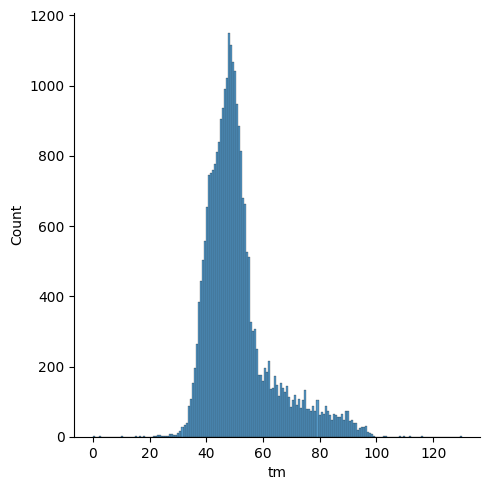

In [22]:
sns.displot(data=thermo_props_final, x='tm')

In [23]:
#sns.displot(data=thermo_props_final, x='log_tm')

In [24]:
correlation_tm = thermo_props_final.corr().sort_values(by='tm', ascending=False)['tm']
correlation_tm

tm    1.000000
A     0.241379
R     0.214278
L     0.204699
G     0.204563
V     0.152576
E     0.089438
P     0.084623
Y     0.056803
pH    0.037574
W     0.018333
I    -0.068630
M    -0.072153
F    -0.074829
H    -0.077988
C    -0.137600
D    -0.150449
K    -0.157391
N    -0.175213
T    -0.193531
Q    -0.225888
S    -0.262857
Name: tm, dtype: float64

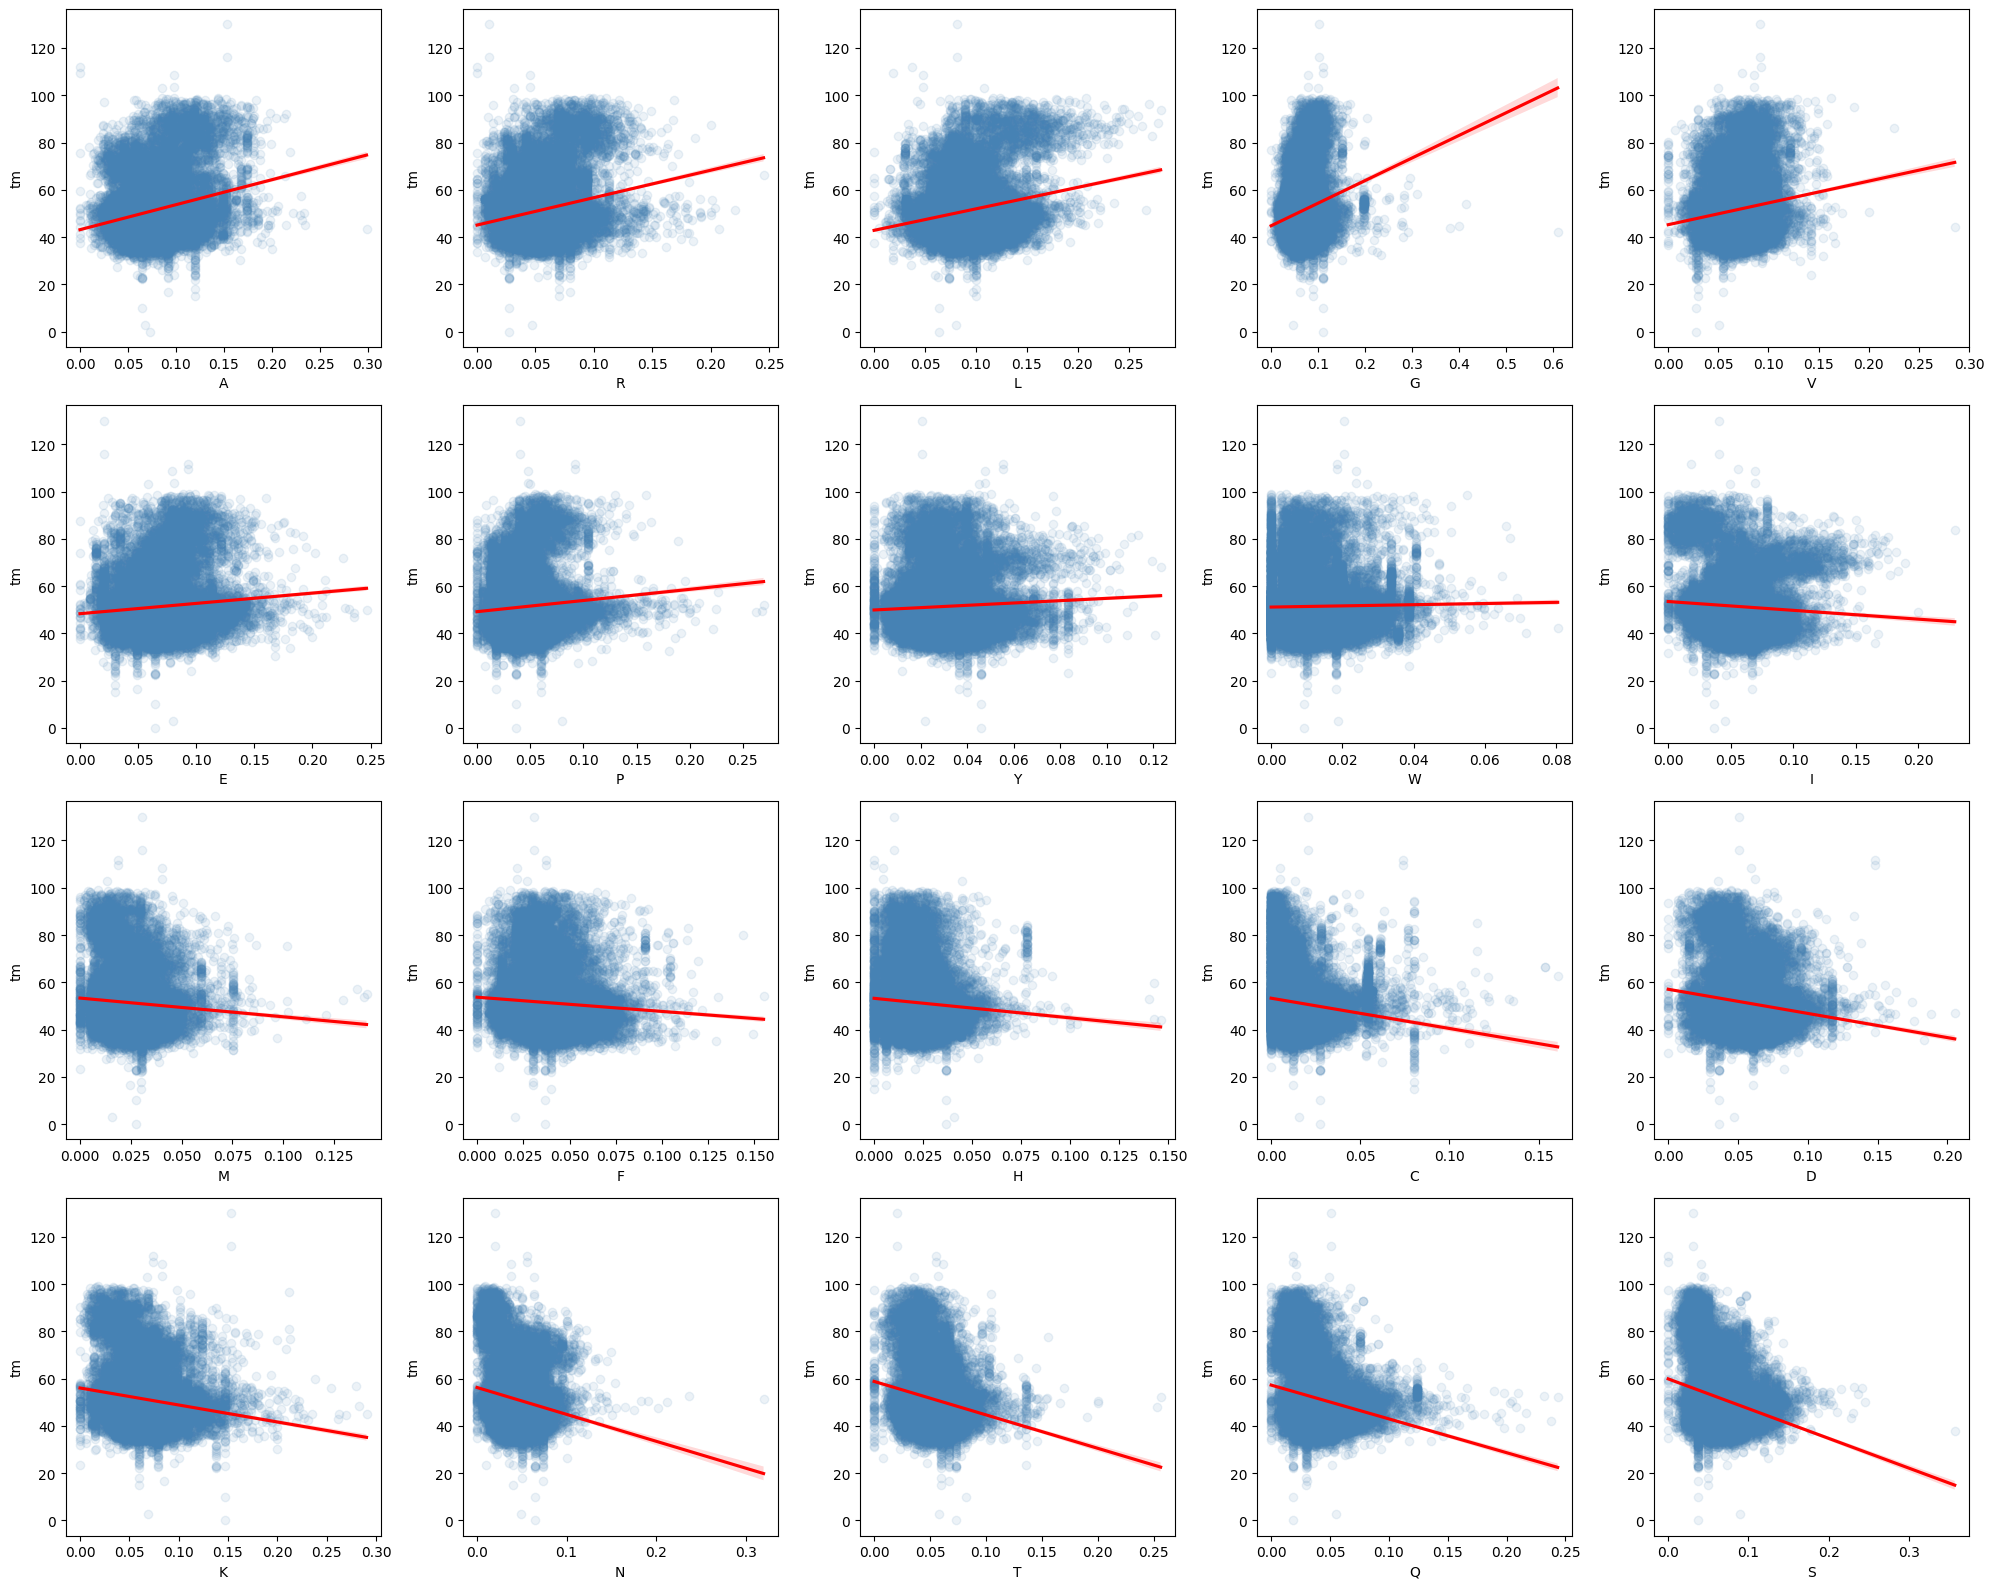

In [25]:
aa_columns = correlation_tm.index.to_list()[1:9] + correlation_tm.index.to_list()[10:]

fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(20, 16))
axes = axes.flatten()  # makes it easier to index as a simple list

for i, aa in enumerate(aa_columns):
    sns.regplot(data=thermo_props_final, x=aa, y='tm', ax=axes[i],
            scatter_kws={'alpha': 0.1, 'color': 'steelblue'},
            line_kws={'color': 'red'})

plt.tight_layout()
plt.show()

##### Prepare Data for Modeling

In [26]:
thermo_props_final

,pH,tm,A,K,L,G,E,P,V,D,...,R,Q,F,M,T,H,S,N,Y,C
0,7.0,75.7,0.131965,0.046921,0.108504,0.111437,0.087977,0.052786,0.108504,0.038123,...,0.073314,0.017595,0.038123,0.023460,0.041056,0.008798,0.032258,0.014663,0.008798,0.002933
1,7.0,50.5,0.097902,0.066434,0.080420,0.062937,0.181818,0.027972,0.045455,0.034965,...,0.104895,0.076923,0.020979,0.006993,0.041958,0.013986,0.048951,0.020979,0.010490,0.000000
2,7.0,40.5,0.100604,0.078471,0.036217,0.130785,0.064386,0.040241,0.060362,0.054326,...,0.062374,0.050302,0.042254,0.012072,0.060362,0.022133,0.066398,0.030181,0.032193,0.018109
3,7.0,47.2,0.075472,0.064151,0.105660,0.060377,0.109434,0.060377,0.052830,0.071698,...,0.037736,0.033962,0.045283,0.007547,0.071698,0.026415,0.060377,0.033962,0.015094,0.018868
4,7.0,49.5,0.059269,0.046864,0.071675,0.057891,0.053756,0.088215,0.085458,0.053756,...,0.043418,0.037216,0.022054,0.021365,0.082702,0.027567,0.101999,0.044797,0.032391,0.009649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27764,7.0,51.8,0.060109,0.058288,0.083789,0.092896,0.056466,0.045537,0.076503,0.069217,...,0.076503,0.043716,0.032787,0.023679,0.032787,0.027322,0.060109,0.043716,0.032787,0.021858
27765,7.0,37.2,0.078891,0.042644,0.100213,0.057569,0.061834,0.040512,0.072495,0.044776,...,0.053305,0.034115,0.046908,0.029851,0.055437,0.046908,0.078891,0.040512,0.029851,0.010661
27766,7.0,64.6,0.101562,0.062500,0.046875,0.085938,0.054688,0.046875,0.054688,0.054688,...,0.023438,0.062500,0.054688,0.054688,0.046875,0.015625,0.078125,0.039062,0.031250,0.007812
27767,7.0,50.7,0.079258,0.059022,0.075885,0.087690,0.060708,0.052277,0.080944,0.057336,...,0.042159,0.020236,0.038786,0.043845,0.053963,0.018550,0.086003,0.042159,0.030354,0.008432


In [27]:
thermo_y = thermo_props_final['tm']
thermo_x = thermo_props_final.drop(columns=['tm'])

### Scikit-learn Imports and Data Split

In [28]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor


from sklearn.metrics import r2_score, root_mean_squared_error


X_train, X_test, y_train, y_test = train_test_split(thermo_x, thermo_y, test_size=0.2, random_state=42)

### Linear Regression

In [29]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin_reg = lin_reg.predict(X_test)

r2_lin_reg = r2_score(y_test, y_pred_lin_reg)
print(f"R2: {r2_lin_reg}")

rmse_lin_reg = root_mean_squared_error(y_test, y_pred_lin_reg)
print(f"RMSE: {rmse_lin_reg}")

R2: 0.2903612128587004
RMSE: 10.316264220602456


### Lasso Regression

In [30]:
lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"R2: {r2_lasso}")

rmse_lasso = root_mean_squared_error(y_test, y_pred_lasso)
print(f"RMSE: {rmse_lasso}")

R2: 0.2904668666606218
RMSE: 10.315496229105651


### Random Forest

In [31]:
random_forest = RandomForestRegressor(random_state=42)
random_forest.fit(X_train, y_train)

y_pred_random_forest = random_forest.predict(X_test)

r2_random_forest = r2_score(y_test, y_pred_random_forest)
print(f"R2: {r2_random_forest}")

rmse_random_forest = root_mean_squared_error(y_test, y_pred_random_forest)
print(f"RMSE: {rmse_random_forest}")

R2: 0.6333556403763589
RMSE: 7.415258381679066


In [32]:
random_forest.feature_importances_


array([0.04496061, 0.0342836 , 0.0385355 , 0.02597347, 0.02493972,
       0.02639405, 0.02273235, 0.03117813, 0.02997988, 0.07287068,
       0.01933301, 0.02863615, 0.11328075, 0.02250468, 0.02462401,
       0.02631241, 0.02377646, 0.1560534 , 0.16263481, 0.02653311,
       0.04446322])

In [33]:
X_train.columns

Index(['pH', 'A', 'K', 'L', 'G', 'E', 'P', 'V', 'D', 'I', 'W', 'R', 'Q', 'F',
       'M', 'T', 'H', 'S', 'N', 'Y', 'C'],
      dtype='str')

<Axes: xlabel='feature', ylabel='importance'>

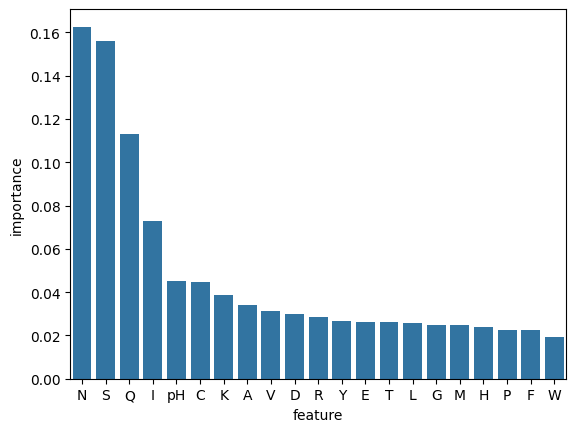

In [34]:
random_forest.feature_importances_
df_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': random_forest.feature_importances_   
}).sort_values(by='importance', ascending=False)
sns.barplot(data=df_importances, x='feature', y='importance')